# MVP - Sistema de Apoio à Decisão: Triagem de Risco Cardíaco

**Aluna:** Giovanna Rodrigues Santiago  
**Disciplina:** Sistemas de Apoio à Decisão  
**Universidade de Brasília (UnB)**

**Situação-problema escolhida:** este MVP foi desenvolvido a partir do problema apresentado no repositório do professor Andre Luiz Marques Serrano ([andrelmsunb/andrelmspucrj3](https://github.com/andrelmsunb/andrelmspucrj3)), que trata da classificação de doenças cardíacas usando o dataset Heart Disease da UCI. Aqui a proposta é uma versão simplificada e introdutória, com um único modelo simples, sem otimização de hiperparâmetros, apenas para demonstrar o fluxo completo de um MVP de sistema de apoio à decisão.

## 1. Definição do problema

**Contexto:** doenças cardíacas estão entre as principais causas de morte no mundo. Identificar precocemente pacientes com risco elevado ajuda médicos a priorizar exames e decidir quais pacientes precisam de atenção mais imediata.

**Decisão que o sistema apoia:** com base em algumas características clínicas simples do paciente (idade, colesterol, pressão, entre outras), o sistema indica se o paciente tem probabilidade alta ou baixa de apresentar doença cardíaca. Essa informação serve como um alerta de triagem, não como diagnóstico definitivo, o médico continua sendo quem decide.

**Tipo de problema:** classificação binária (com doença / sem doença).

**Dataset:** Heart Disease, UCI Machine Learning Repository (id 45), 303 pacientes, 13 atributos clínicos.

## 2. Preparação do ambiente

In [12]:
!pip install ucimlrepo -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

sns.set(style="whitegrid")

## 3. Carga dos dados

Os dados são carregados diretamente do repositório oficial da UCI, usando o pacote `ucimlrepo`.

In [13]:
from ucimlrepo import fetch_ucirepo

heart_disease = fetch_ucirepo(id=45)

X = heart_disease.data.features
y = heart_disease.data.targets

df = X.copy()
df["num"] = y

print(df.shape)
df.head()

(303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


## 4. Entendimento dos dados

Uma exploração simples: tipos de dados, valores ausentes e como o alvo (presença de doença) está distribuído.

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  num       303 non-null    int64  
dtypes: float64(3), int64(11)
memory usage: 33.3 KB


In [15]:
df.isna().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [16]:
df["num"].value_counts().sort_index()

,count
num,
0,164
1,55
2,36
3,35
4,13


/tmp/ipykernel_976/3721703201.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="num", data=df, palette="Blues")


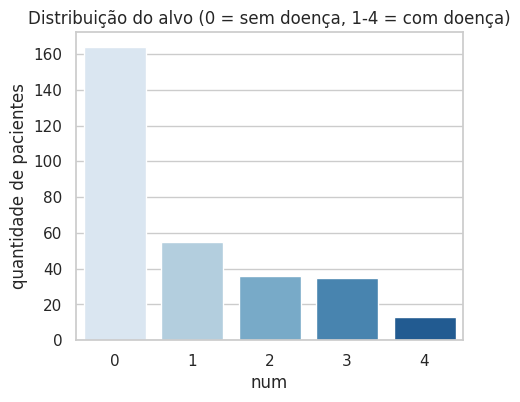

In [17]:
plt.figure(figsize=(5,4))
sns.countplot(x="num", data=df, palette="Blues")
plt.title("Distribuição do alvo (0 = sem doença, 1-4 = com doença)")
plt.xlabel("num")
plt.ylabel("quantidade de pacientes")
plt.show()

## 5. Preparação dos dados

Passos simples para este MVP:
1. Transformar o alvo em binário (0 = sem doença, 1 = com doença, juntando os graus 1 a 4)
2. Remover as poucas linhas com valores ausentes
3. Separar treino e teste
4. Padronizar as variáveis numéricas

In [18]:
df_prep = df.dropna().copy()

df_prep["target"] = (df_prep["num"] > 0).astype(int)
df_prep = df_prep.drop(columns=["num"])

print("Formato após limpeza:", df_prep.shape)
df_prep["target"].value_counts()

Formato após limpeza: (297, 14)


,count
target,
0,160
1,137


In [19]:
X_prep = df_prep.drop(columns=["target"])
y_prep = df_prep["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X_prep, y_prep, test_size=0.2, random_state=42, stratify=y_prep
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Treino:", X_train.shape, " Teste:", X_test.shape)

Treino: (237, 13)  Teste: (60, 13)


## 6. Modelagem

Para este MVP, foi escolhido um único modelo simples e interpretável: **Regressão Logística**. A ideia de um MVP é validar rápido se a abordagem funciona, sem ainda investir em comparação de vários algoritmos ou ajuste fino de hiperparâmetros (isso pode ser feito em uma versão futura).

In [20]:
modelo = LogisticRegression(max_iter=1000, random_state=42)
modelo.fit(X_train_scaled, y_train)

y_pred = modelo.predict(X_test_scaled)

## 7. Avaliação do modelo

In [21]:
acuracia = accuracy_score(y_test, y_pred)
print(f"Acurácia no conjunto de teste: {acuracia:.2%}")
print()
print(classification_report(y_test, y_pred, target_names=["Sem doença", "Com doença"]))

Acurácia no conjunto de teste: 83.33%

              precision    recall  f1-score   support

  Sem doença       0.82      0.88      0.85        32
  Com doença       0.85      0.79      0.81        28

    accuracy                           0.83        60
   macro avg       0.83      0.83      0.83        60
weighted avg       0.83      0.83      0.83        60



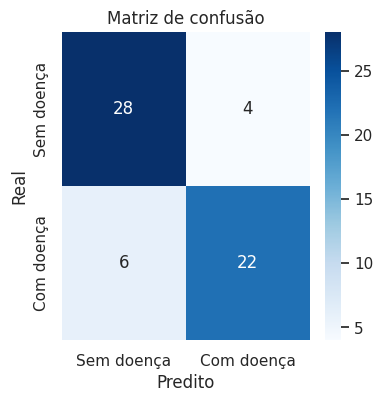

In [22]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(4,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Sem doença", "Com doença"],
            yticklabels=["Sem doença", "Com doença"])
plt.xlabel("Predito")
plt.ylabel("Real")
plt.title("Matriz de confusão")
plt.show()

## 8. Conclusão do MVP

**O que o sistema faz:** a partir de atributos clínicos simples, o modelo indica se um paciente tem probabilidade alta ou baixa de ter doença cardíaca, servindo como um sinal de alerta para triagem.

**Como apoia a decisão:** o médico pode usar essa indicação como um critério a mais, junto de outros exames, para decidir quais pacientes priorizar. O sistema não substitui o julgamento clínico, é uma ferramenta de apoio.

**Limitações desta primeira versão (MVP):**
- Apenas um modelo foi testado (Regressão Logística), sem comparação com outros algoritmos
- Não houve ajuste de hiperparâmetros
- Dataset pequeno (303 pacientes) e antigo
- Linhas com valores ausentes foram simplesmente removidas

**Próximos passos (evolução do MVP):**
- Testar outros algoritmos (Random Forest, SVM, KNN) e comparar desempenho
- Fazer ajuste de hiperparâmetros com validação cruzada
- Tratar os valores ausentes com imputação em vez de remoção
- Avaliar a importância de cada variável na decisão do modelo